# Table of Contents

* [1.1 Introduction](#1.1-Introduction)
* [1.2 Preparation](#1.2-Preparation)
    * [1.2.1 Import the dataset](#1.2.1-Import-the-dataset)
* [1.3 Dataset Summary ](#1.3-Dataset-Summary)
* [1.4 Missing Values and Duplicates analysis](#1.4-Missing-Values-and-Duplicates-analysis)
    * [1.4.1 Missing Values](#1.4.1-Missing-Values)
    * [1.4.2 Duplicates](#1.4.2-Duplicates)
* [1.5 Univariate Analysis](#1.5-Univariate-Analysis)
    * [1.5.1 Numerical Variables](#1.5.1-Numerical-Variables)
    * [1.5.2 Outliers Analysis](#1.5.2-Outliers-Analysis)
    * [1.5.3 Categorical Variables](#1.5.3-Categorical-Variables)
* [1.6 Bivariate Analysis](#1.6-Bivariate-Analysis)
    * [1.6.1 Correlation Matrix](#1.6.1-Correlation-Matrix)
    * [1.6.2 Contingency Table](#1.6.2-Contingency-Table)
    * [1.6.3 Notes for Supervised Learning Preprocessing](#1.6.3-Notes-for-Supervised-Learning-Preprocessing)
* [1.7 Final Insights](#1.7-Final-Insights)

# 1.1 Introduction

This notebook performs an Exploratory Data Analysis (EDA) on the `customer_info.csv` dataset. We focus on data quality (missing values, duplicates, outliers) and feature engineering to prepare the data for predictive modeling.

# 1.2 Preparation

Loading necessary libraries and setting plot styles.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import math

## 1.2.1 Import the dataset

In [3]:
file_path = 'C:\\Users\\maria\\Documents\\Universidade\\Machine Learning II\\Customer-Segmentation-Project\\Course Assignment - Customer Segmentation-20260417\\customer_info.csv'
df = pd.read_csv(file_path)
df.head()

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


# 1.3 Dataset Summary

In [17]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   customer_id                              33038 non-null  int64         
 1   customer_name                            33038 non-null  object        
 2   customer_gender                          33038 non-null  object        
 3   customer_birthdate                       32873 non-null  datetime64[ns]
 4   kids_home                                32708 non-null  float64       
 5   teens_home                               32708 non-null  float64       
 6   number_complaints                        32377 non-null  float64       
 7   distinct_stores_visited                  32708 non-null  float64       
 8   lifetime_spend_groceries                 33038 non-null  float64       
 9   lifetime_spend_electroni

In [ ]:
print("\nNumerical Description:")
display(df.describe()) 


Numerical Description:


,customer_id,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,...,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude,birth_month,birth_year,birth_day
count,33038.000000,32873,32708.000000,32708.000000,32377.000000,32708.000000,33038.000000,32377.000000,32377.000000,32377.000000,...,32377.000000,33038.000000,32708.000000,33038.000000,19932.0,33038.000000,33038.000000,32873.000000,32873.000000,32873.000000
mean,19974.265785,1971-05-20 20:35:28.913089768,1.116118,0.898893,0.930846,3.167941,16306.227798,2763.080088,12.659388,727.223801,...,336.217099,148.914644,0.318866,2015.311853,1.0,38.749694,-9.154549,6.553342,1970.879749,15.827488
min,3.000000,1940-01-02 06:03:00,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000,...,0.000000,0.000000,-1.274940,1993.000000,1.0,38.687987,-9.232989,1.000000,1940.000000,1.000000
25%,9985.250000,1955-09-04 09:16:00,0.000000,0.000000,0.000000,2.000000,8647.000000,579.000000,8.000000,224.000000,...,225.000000,67.000000,0.122359,2012.000000,1.0,38.734079,-9.173732,4.000000,1955.000000,8.000000
50%,19951.500000,1971-07-05 14:59:00,1.000000,1.000000,1.000000,3.000000,13002.500000,1470.000000,12.000000,471.000000,...,327.000000,123.000000,0.239449,2015.000000,1.0,38.748286,-9.156689,7.000000,1971.000000,16.000000
75%,29964.750000,1987-03-30 14:07:00,1.000000,1.000000,1.000000,4.000000,20807.000000,3745.000000,16.000000,1074.000000,...,435.000000,210.000000,0.469390,2019.000000,1.0,38.765779,-9.139608,10.000000,1987.000000,23.000000
max,40000.000000,2002-01-01 07:25:00,8.000000,6.000000,7.000000,10.000000,104670.000000,35299.000000,23.000000,3337.000000,...,1224.000000,600.000000,1.000000,2029.000000,1.0,38.823693,-9.035697,12.000000,2002.000000,31.000000
std,11538.538632,NaN,1.150186,0.962924,0.894658,1.674114,11985.903518,3453.191495,4.854708,654.633087,...,160.234980,105.922907,0.283638,5.032196,0.0,0.022498,0.028581,3.446549,18.064552,8.819905


# 1.4 Missing Values and Duplicates analysis

## 1.4.1 Missing Values

In [6]:
null_counts = df.isnull().sum()
missing_df = pd.DataFrame({
    'Missing Values': null_counts
}).sort_values(by='Missing Values', ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df['Missing Values'] >= 0])

Missing Values Summary:
                                         Missing Values
loyalty_card_number                               13106
lifetime_spend_fish                                 991
lifetime_spend_electronics                          661
lifetime_spend_videogames                           661
lifetime_spend_meat                                 661
lifetime_spend_vegetables                           661
typical_hour                                        661
lifetime_spend_petfood                              661
number_complaints                                   661
distinct_stores_visited                             330
percentage_of_products_bought_promotion             330
teens_home                                          330
lifetime_spend_alcohol_drinks                       330
kids_home                                           330
lifetime_spend_hygiene                              330
customer_birthdate                                  165
year_first_transaction  

Most features have a manageable number of missing values — around 330 to 991 rows — likely corresponding to the same subset of customers with incomplete records, suggesting the missingness is structural rather than random. 

The clear outlier is `loyalty_card_number` with **13,106 missing values**. This is almost certainly not random — it simply means those customers do not have a loyalty card, so its absence is meaningful in itself. Imputing this column would make no sense, and since it is a pure identifier with no behavioural signal, it will be dropped entirely in preprocessing

## 1.4.2 Duplicates

This section verifies whether the dataset contains repeated entries.
- `df.duplicated().sum()` counts rows that are exactly the same across all columns.
- `df['customer_id'].duplicated().sum()` checks whether the same customer ID appears more than once.

A duplicate customer ID is important because `customer_id` should uniquely identify each customer. If the same ID repeats, the dataset may contain:
- exact duplicate records, or
- conflicting information for the same customer. 

In [7]:
print(f"Full row duplicates: {df.duplicated().sum()}")
print(f"Duplicate Customer IDs: {df['customer_id'].duplicated().sum()}")

Full row duplicates: 0
Duplicate Customer IDs: 0


# 1.5 Univariate Analysis

## 1.5.1 Numerical Variables

Here we are selecting the numerical variables for  some analysis, even thought the *id* feature is considered a numerical variable we´re not considering it for the future analysis because there is no pattern or relevant information for our future model since it's only an identification of our records

In [24]:
numeric_cols = [
    "kids_home",
    "teens_home",
    "number_complaints",
    "distinct_stores_visited",
    "lifetime_spend_groceries",
    "lifetime_spend_electronics",
    "typical_hour",
    "lifetime_spend_vegetables",
    "lifetime_spend_nonalcohol_drinks",
    "lifetime_spend_alcohol_drinks",
    "lifetime_spend_meat",
    "lifetime_spend_fish",
    "lifetime_spend_hygiene",
    "lifetime_spend_videogames",
    "lifetime_spend_petfood",
    "lifetime_total_distinct_products",
    "percentage_of_products_bought_promotion",
    "year_first_transaction",
    "loyalty_card_number",
    "latitude",
    "longitude"
]

In [30]:
num_cols = df.drop(columns=['customer_id','customer_name','customer_gender','customer_birthdate'])

### Constant Variables

In [31]:
num_cols.var()

kids_home                                  1.322927e+00
teens_home                                 9.272217e-01
number_complaints                          8.004128e-01
distinct_stores_visited                    2.802657e+00
lifetime_spend_groceries                   1.436619e+08
lifetime_spend_electronics                 1.192453e+07
typical_hour                               2.356819e+01
lifetime_spend_vegetables                  4.285445e+05
lifetime_spend_nonalcohol_drinks           7.604798e+04
lifetime_spend_alcohol_drinks              2.680592e+05
lifetime_spend_meat                        2.333110e+05
lifetime_spend_fish                        2.470775e+05
lifetime_spend_hygiene                     3.700500e+05
lifetime_spend_videogames                  2.123201e+05
lifetime_spend_petfood                     2.567525e+04
lifetime_total_distinct_products           1.121966e+04
percentage_of_products_bought_promotion    8.045041e-02
year_first_transaction                     2.532

Checking for constant variables — features with zero variance that carry no information for clustering — only `loyalty_card_number` has a variance of exactly **0.0**, confirming it is a constant and will be dropped in preprocessing.

All other features show non-zero variance. Notably, `latitude` and `longitude` have extremely low variance (~5e-04 and ~8e-04 respectively).While not technically constant, their near-zero variance makes them unlikely to contribute meaningful separation in clustering, so they will likely be dropped as well.

### Distribution of each feature 
Histograms help visualize how each numeric variable is distributed, showing skewness, central tendency, and spread.

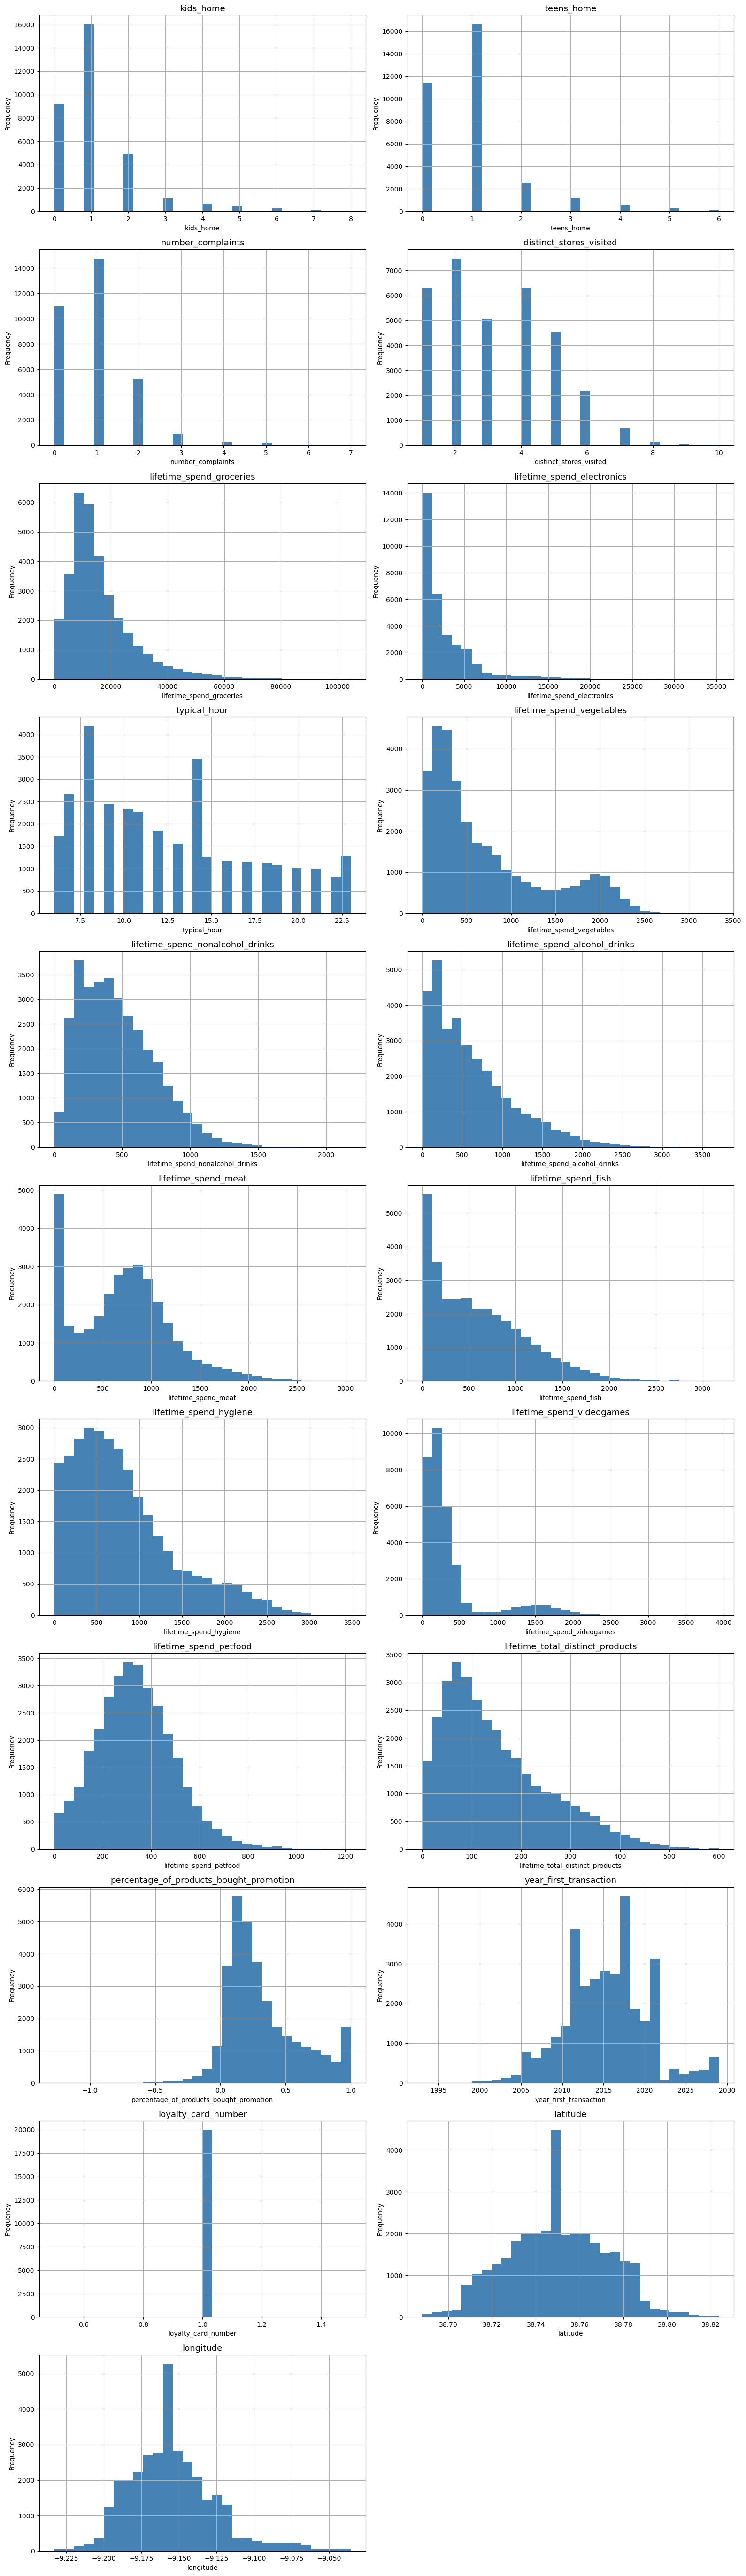

In [20]:
cols_per_row = 2
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / cols_per_row)

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=30, color='steelblue', ax=axes[i])
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Esconder eixos vazios se o número de colunas for ímpar
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Conclusions about the Numerical Data Distribution

After analyzing the histograms above, several insights can be drawn regarding the distribution of the numerical features.

### The Shape of the Distributions

We can characterize the overall shape of each variable based on its histogram:

- **Right-Skewed Variables (log transformation candidates):** `lifetime_spend_groceries`, `lifetime_spend_electronics`, `lifetime_spend_vegetables`, `lifetime_spend_nonalcohol_drinks`, `lifetime_spend_alcohol_drinks`, `lifetime_spend_meat`, `lifetime_spend_fish`, `lifetime_spend_hygiene`, `lifetime_spend_petfood`, `lifetime_total_distinct_products` and `lifetime_spend_videogames` have most observations concentrated near zero, with a long right tail representing a few high spenders. We will apply log transformation to these features in the preprocessing phase to make their distributions more normal.

- **Approximately Normal (no action needed):** `lifetime_spend_petfood` show a roughly symmetric, bell-shaped distribution, indicating consistent spending behaviour across customers.

- **Uniform-like:** `distinct_stores_visited` is relatively spread across its range with no dominant peak, suggesting customers visit a varied number of stores without a clear pattern.

- **Discrete / Sparse:** `kids_home`, `teens_home` and `number_complaints` are heavily concentrated at 0 and 1 with very few higher values. These are low-variance features and their usefulness for clustering should be evaluated.

### Other Notes

`typical_hour` shows a bimodal pattern with peaks around 8–9am and 15pm, which could be meaningful for segmentation. `year_first_transaction` has visible spikes that likely reflect onboarding campaigns or data collection changes over the years. `percentage_of_products_bought_promotion` presents negative values, which is worth investigating before preprocessing. Finally, `loyalty_card_number` will be dropped as it is a pure identifier with no distributional value.


### Whiskers and Outliers

This section uses boxplots to visually identify outliers and compare the spread of numerical variables.

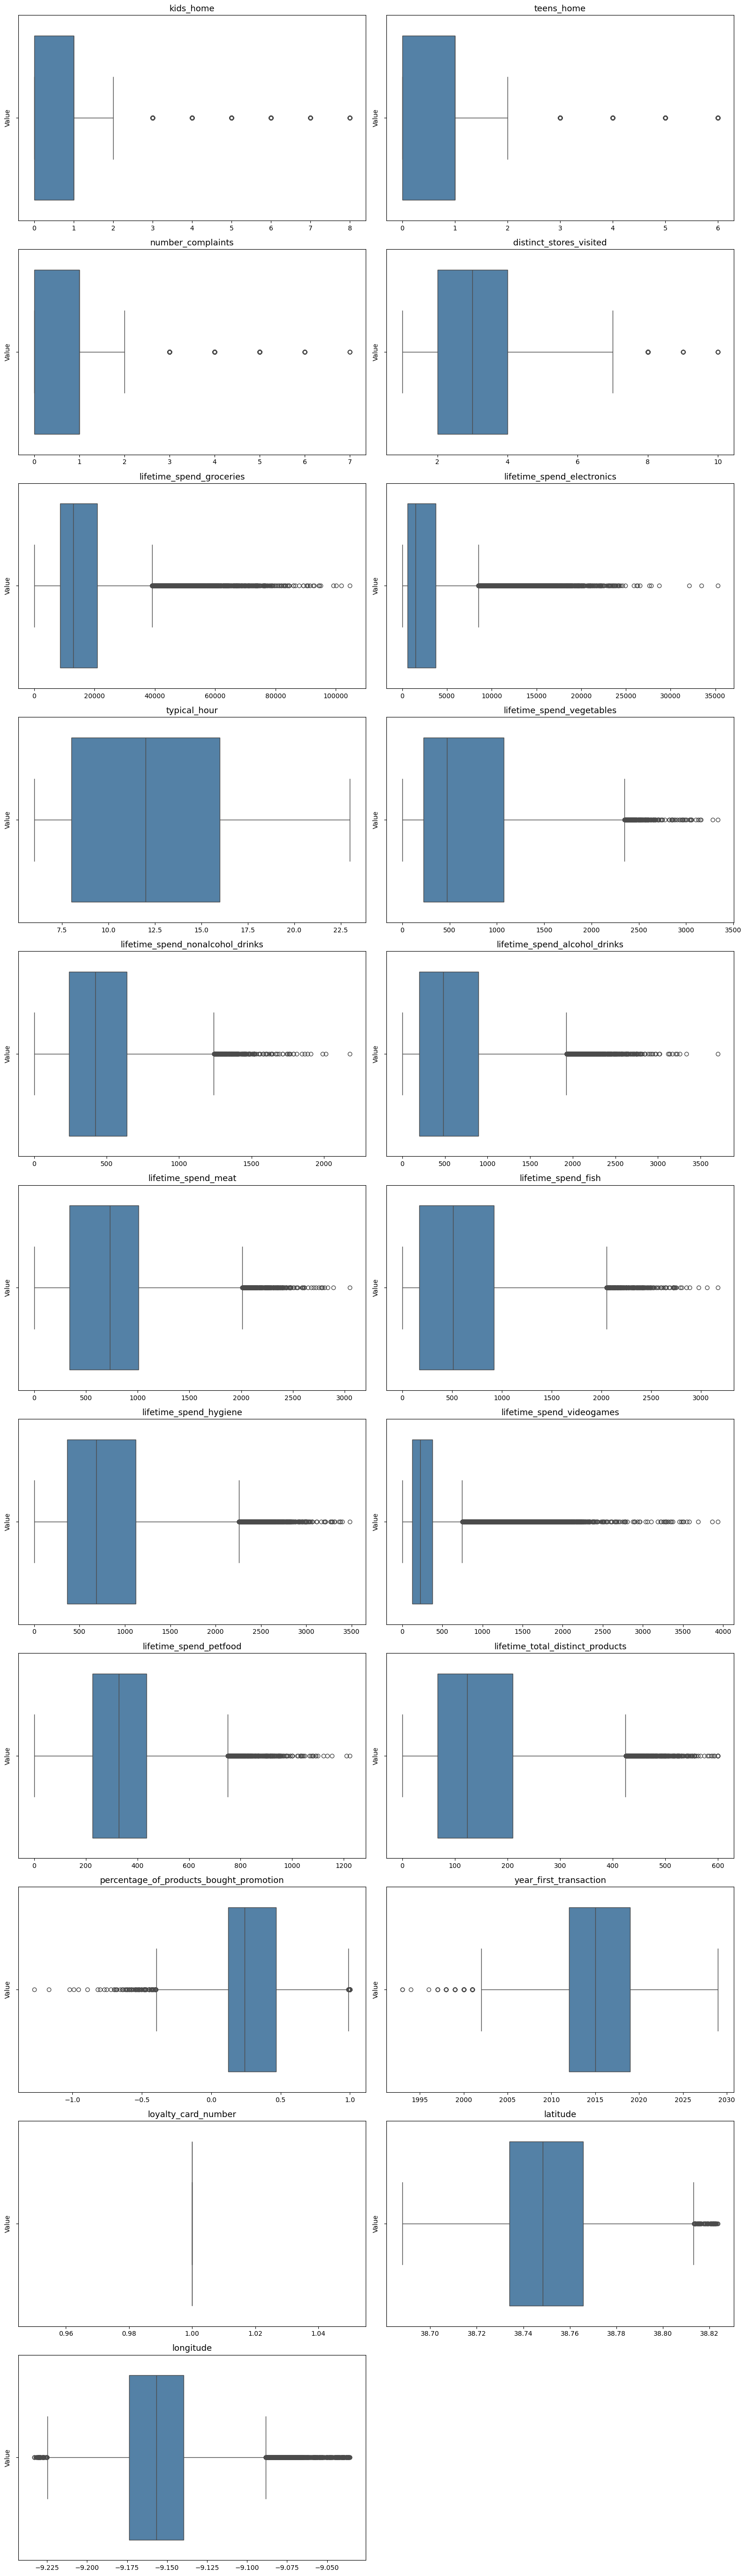

In [22]:
cols_per_row = 2
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / cols_per_row)

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], color='steelblue', ax=axes[i])
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Value')

for ax in axes[len(numeric_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Conclusions about the Outliers

After analyzing the boxplots above, several insights can be drawn regarding the presence and severity of outliers across features.

### Outlier Severity

We can characterize each variable by its outlier behaviour:

- **Heavy outliers (require treatment):** `lifetime_spend_groceries`, `lifetime_spend_electronics`, `lifetime_spend_nonalcohol_drinks`, `lifetime_spend_alcohol_drinks`, `lifetime_spend_meat`, `lifetime_spend_fish`, `lifetime_spend_hygiene`, `lifetime_spend_videogames`, `lifetime_spend_petfood` and `lifetime_total_distinct_products` all show a dense cloud of outliers stretching far into the right tail. These are consistent with the right-skewed distributions observed in the histograms, and confirm that log transformation followed by outlier capping will be necessary in preprocessing.

- **Moderate outliers (worth monitoring):** `kids_home`, `teens_home`, `number_complaints` and `lifetime_spend_vegetables` show a small number of isolated outlier points beyond the whiskers. Given that these are discrete or low-variance features, the outliers likely represent genuine edge cases rather than noise.

- **No meaningful outliers:** `distinct_stores_visited` and `typical_hour` show clean distributions with whiskers covering most of the range and very few points outside, suggesting no aggressive treatment is needed.

### Other Notes

`percentage_of_products_bought_promotion` shows outliers on the **left tail**, around -1.0, reinforcing the data quality concern raised in the histogram analysis — negative percentages are not interpretable and should be investigated. `year_first_transaction` has a few early outliers around 1995–2000, which likely correspond to the oldest customers in the dataset. `loyalty_card_number` shows no variance whatsoever in the boxplot, further confirming it should be dropped. `latitude` and `longitude` both present outlier clusters at the edges of their ranges, but given the overall tight geographic spread, these likely just reflect customers at the boundary of the Lisbon area.

## 1.5.2 Categorical Variables

### Customer Gender

In this bar chart we can clearly see that the distribution is nearly perfectly balanced, with approximately **16,600 female** and **16,500 male** customers. 

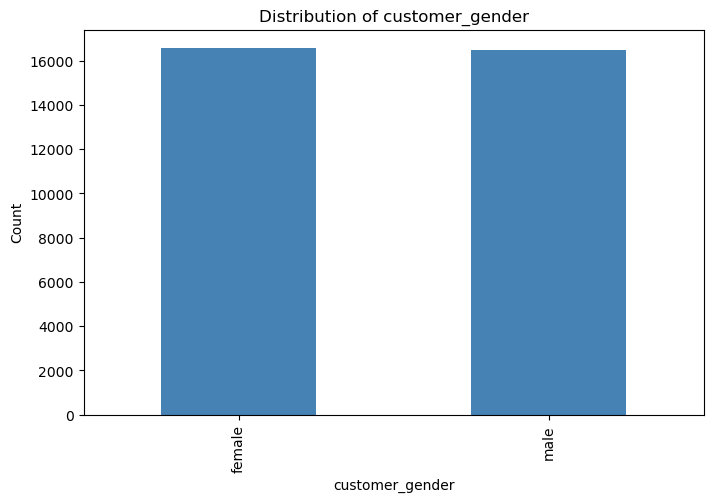

In [11]:
cat_cols = ['customer_gender']
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    df[col].value_counts().plot(kind='bar', color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.ylabel('Count')
    plt.show()

### Customer Birthdate

In this section we convert `customer_birthdate` to a datetime type and extract `birth_month`, `birth_year`, and `birth_day`. Then we visualize the number of customers born in each month to identify seasonal patterns and insights for customer segmentation.

C:\Users\maria\AppData\Local\Temp\ipykernel_3312\765774550.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='birth_year', data=df, palette='Blues_d')


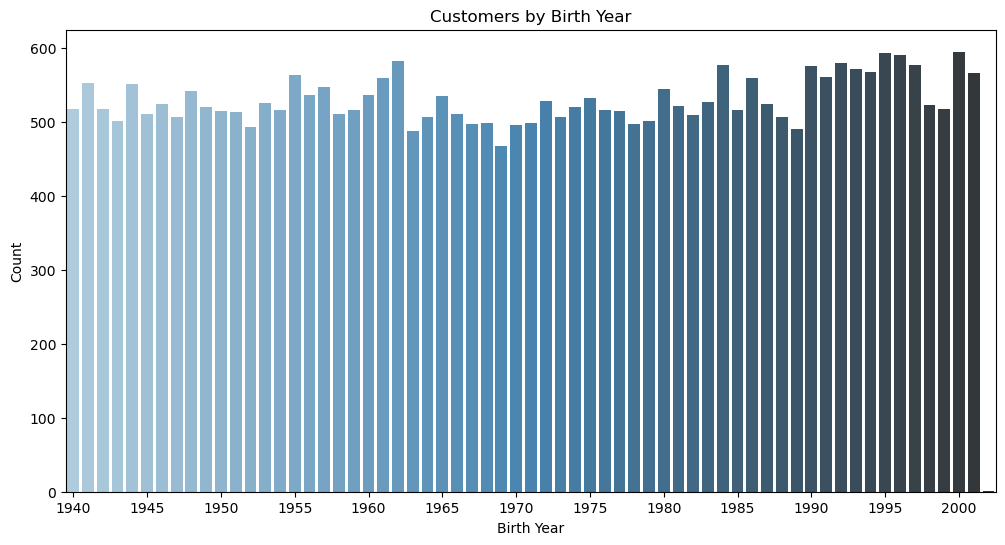

In [37]:
df['customer_birthdate'] = pd.to_datetime(df['customer_birthdate'], errors='coerce')
df['birth_month'] = df['customer_birthdate'].dt.month
df['birth_year'] = df['customer_birthdate'].dt.year
df['birth_day'] = df['customer_birthdate'].dt.day

plt.figure(figsize=(12, 6))
ax = sns.countplot(x='birth_year', data=df, palette='Blues_d')
ax.set_title('Customers by Birth Year')
ax.set_xlabel('Birth Year')
ax.set_ylabel('Count')
ax.set_xticks(ax.get_xticks()[::5]) # show every 5th year only
ax.set_xticklabels([int(float(label.get_text())) for label in ax.get_xticklabels()])
plt.show()

The distribution of customers by birth year is remarkably **uniform across the entire range**, from **1940 to 2002**, with each year consistently sitting between 470 and 600 customers and no dominant age group standing out. This suggests the dataset was likely **synthetically generated or deliberately balanced by age**, as a real-world customer base would rarely be this evenly spread across 60+ birth years.


# 1.6 Bivariate Analysis

## 1.6.1 Correlation Matrix

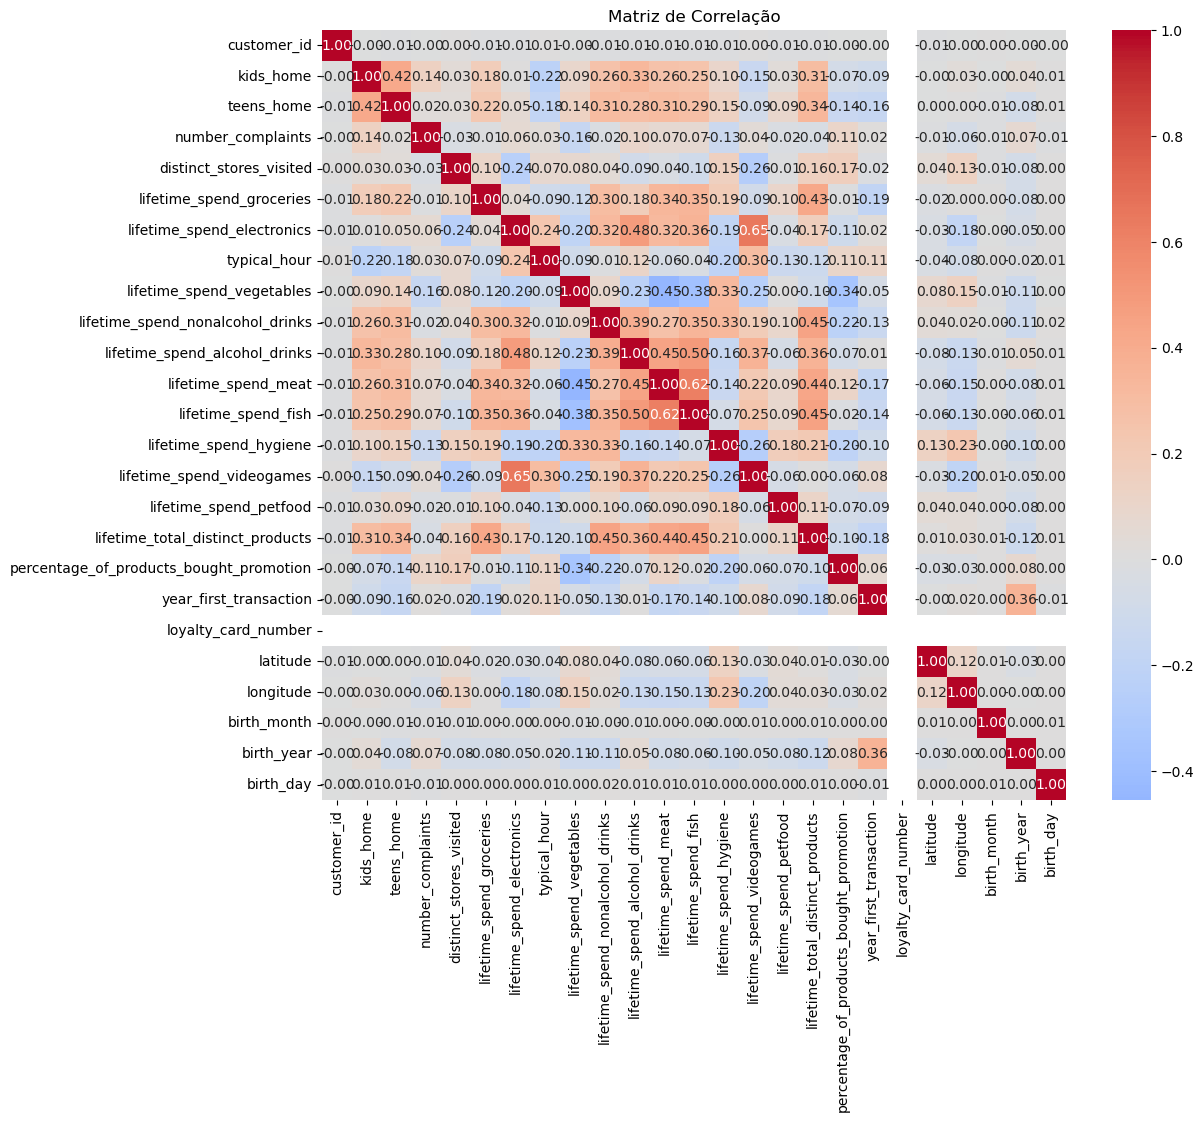

In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlação")
plt.show()



Most features are weakly correlated, but spending categories clearly move together. Customers who buy meat also tend to buy fish (~0.62), and heavy grocery spenders also spend more on videogames (~0.65). This suggests there are distinct spending profiles worth clustering around.

Family structure also shows up — kids and teens at home are moderately linked (~0.42), and both show a slight negative pull on spending, meaning families tend to spend less freely across categories.

`customer_id` and `loyalty_card_number` are pure identifiers with no behavioural meaning, so they will be dropped. `birth_month` and `birth_day` are also likely to go since they carry no meaningful signal about customer behaviour — unlike `birth_year`, which we will keep as it encodes age.


# 1.7 Final Insights

